<a href="https://colab.research.google.com/github/jarrodsb/ETAMU-binary-systems/blob/main/notebooks/Example_Three_body_Stability.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Three-body Stability

## Jarrod Bieber
## East Texas A&M University
## Summer 2026
---

In [ ]:
!pip install rebound

In [ ]:
import rebound
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as cm
import os
from scipy.interpolate import CloughTocher2DInterpolator

## S-Type Orbit $\rho_{cr}$
---

In [ ]:
mu = 0.5
ebin = 0.5

github_file = "https://raw.githubusercontent.com/saturnaxis/CBP_stability/master/a_crit.txt"
X,Y,Z = np.genfromtxt(github_file,delimiter=',',comments='#',unpack=True)

f = CloughTocher2DInterpolator(np.array([X,Y]).T,Z)

astab = f(mu,ebin)
print("For mu = %1.2f, e_bin = %1.2f, the critical semimajor axis ratio rho_cr = %1.2f" % (mu, ebin,astab))


For mu = 0.50, e_bin = 0.50, the critical semimajor axis ratio rho_cr = 3.54


## P-Type Orbit $\rho_{cr}$
---

In [ ]:
mu = 0.2937/(1 + 0.2937)  #converting from q --> mu  Doyle et al. (2011)
ebin = 0.15944

github_file = "https://raw.githubusercontent.com/saturnaxis/CBP_stability/master/a_crit.txt"
X,Y,Z = np.genfromtxt(github_file,delimiter=',',comments='#',unpack=True)

f = CloughTocher2DInterpolator(np.array([X,Y]).T,Z)

astab = f(mu,ebin)
print("For mu = %1.2f, e_bin = %1.2f, the critical semimajor axis ratio rho_cr = %1.2f" % (mu, ebin,astab))

For mu = 0.23, e_bin = 0.16, the critical semimajor axis ratio rho_cr = 2.70


## Sample Simulation Kepler-16b (P-type Planet)
---

In [ ]:
M_J = 9.54e-4 #Jupiter mass in Msun

#Kepler-16 parameters from Doyle et al. (2011)
M_A = 0.6897 #mass of star A in Msun
M_B = 0.20255 #mass of star B in Msun
a_bin = 0.22431 #binary semimajor axis in AU
T_bin = 41.079220/365.25 #binary orbital period in yr
e_bin = 0.15944 #binary eccentricity
inc_bin = np.radians(90.30401) #binary inclination on the sky plane
omg_bin = np.radians(263.464) #binary argument of periapse
RA_bin = 0 #binary longitude of nodes
MA_bin = np.radians(92.352) - omg_bin #binary mean anomaly from mean longitude

M_p = 0.333*M_J
a_p = 0.7048 #planet semimajor axis in AU
T_p = 228.776/365.25 #planetary orbital period in yr
e_p = 0.0069
inc_p = np.radians(90.0322) #planetary inclination on the sky plane
omg_p = np.radians(318) #planetary argument of periapse
RA_p = np.radians(0.003) # planetary longitude of nodes
MA_p = np.radians(106.51) - omg_p #planetary mean anomaly from mean longitude

## Define simulation for a binary star system and a P-type planet

In [ ]:
def simulation_P(tscale,fname,out_step):
    sim = rebound.Simulation()
    sim.integrator = 'ias15'
    sim.units = ('AU','yr','Msun')
    sim.dt = 0.025*T_bin

    sim.add(m=M_A)
    sim.add(m=M_B,a=a_bin,e=e_bin,inc=inc_bin,omega=omg_bin,Omega=RA_bin,M=MA_bin)
    sim.move_to_com()
    sim.add(m=M_p,a=a_p,e=e_p,inc=inc_p,omega=omg_p,Omega=RA_p,M=MA_p)

    sim.save_to_file(fname,step=out_step,delete_file=True)
    sim.integrate(tscale)

## Run the simulation for 10 years

In [ ]:
output_bin = "Kepler16.bin"
output_steps = 20
simulation_P(10,output_bin,output_steps)

## Method to rotate the Position Vector to give a face-on view of the system

In [ ]:
def Rot(ang1,ang2,x):
    rot_omg = np.array([[np.cos(ang1),-np.sin(ang1),0],[np.sin(ang1),np.cos(ang1),0],[0,0,1]])
    rot_inc = np.array([[1, 0, 0], [0,np.cos(ang2),-np.sin(ang2)],[0,np.sin(ang2),np.cos(ang2)]])
    rot_mat = np.dot(rot_omg,rot_inc)
    return np.dot(rot_mat,x)

## Plot the Simulation

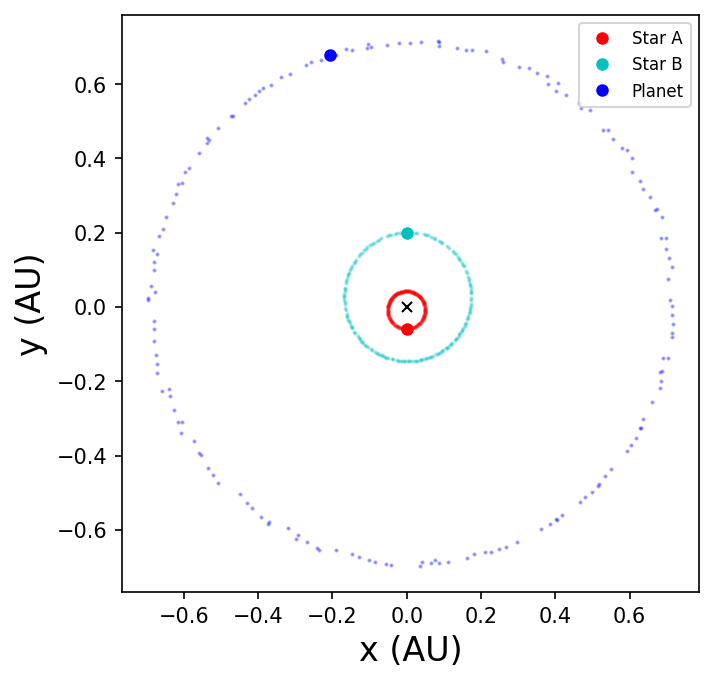

In [ ]:
sa = rebound.Simulationarchive(output_bin)

fig = plt.figure(figsize=(5,5),dpi=150)
ax = fig.add_subplot(111)
ax.set_aspect('equal')

ax.plot(0,0,'kx',ms=5)
xy_coords = np.zeros((len(sa),6))
for s in range(0,len(sa)):
    sim = sa[s] #iterate through each snapshot in sa
    ps = sim.particles #intermediate object to simplify the referencing
    sim.move_to_com() #shift to center-of-mass coordinates
    for p in range(0,len(ps)):
        Cart = np.array([ps[p].x, ps[p].y, ps[p].z])
        rot_xy = Rot(-ps[1].Omega,-ps[1].inc,Cart) # (Longitude of ascending node, inclination, particle in Cartesian coordinates)
        xy_coords[s,2*p] = rot_xy[0]
        xy_coords[s,2*p+1] = rot_xy[1]

color = ['r','c','b']
label = ['Star A','Star B','Planet']
for p in range(0,3):
    ax.plot(xy_coords[:,2*p],xy_coords[:,2*p+1],'.',color=color[p],ms=2,alpha=0.3)
    ax.plot(xy_coords[0,2*p],xy_coords[0,2*p+1],'.',color=color[p],label=label[p],ms=10)

ax.set_xlabel("x (AU)",fontsize=16)
ax.set_ylabel("y (AU)",fontsize=16)
plt.legend(loc='upper right',fontsize=8);

## Run a 100-year simulation to see two full precessions of the planet's apoapsis due to perturbances from the binary

In [ ]:
output_bin = "Kepler16_long.bin"
output_steps = 200
simulation_P(100,output_bin,output_steps)

## Plot a series of figures to show how the orbit is changing with time

forced eccentricity e_F = 0.034; forced periapse w_F = 281.361


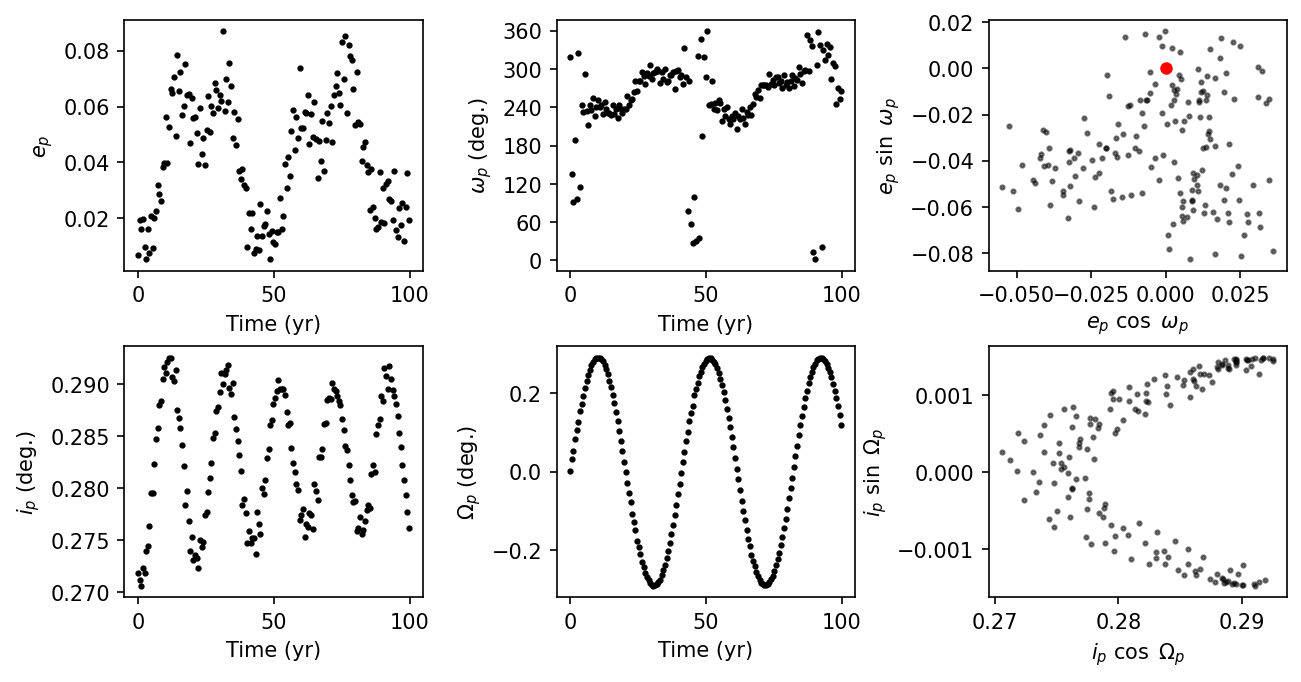

In [ ]:
sa = rebound.Simulationarchive(output_bin)

fig = plt.figure(figsize=(10,5),dpi=150)
ax11 = fig.add_subplot(231)
ax12 = fig.add_subplot(232)
ax13 = fig.add_subplot(233)
ax21 = fig.add_subplot(234)
ax22 = fig.add_subplot(235)
ax23 = fig.add_subplot(236)

pl_orb = np.zeros((len(sa),6))
time = np.zeros(len(sa))
for s in range(0,len(sa)):
    sim = sa[s] #iterate through each snapshot in sa
    ps = sim.particles #intermediate object to simplify the referencing
    sim.move_to_com() #shift to center-of-mass coordinates
    time[s] = sim.t
    del_Omega = ps[2].Omega - ps[1].Omega
    omg_p = ps[2].omega
    mut_incl = np.arccos(np.cos(ps[1].inc)*np.cos(ps[2].inc) + np.sin(ps[1].inc)*np.sin(ps[2].inc)*np.cos(del_Omega))
    pl_orb[s,:] = [ps[2].a,ps[2].e,np.degrees(mut_incl),omg_p,del_Omega,ps[2].M]

#calculate the vector components of eccentricity and inclination
ecosw, esinw = pl_orb[:,1]*np.cos(pl_orb[:,3]), pl_orb[:,1]*np.sin(pl_orb[:,3])
icosO, isinO = pl_orb[:,2]*np.cos(pl_orb[:,4]), pl_orb[:,2]*np.sin(pl_orb[:,4])

e_F = np.sqrt(np.mean(ecosw)**2 + np.mean(esinw)**2)
w_F = np.mean(np.arctan2(esinw,ecosw))
print("forced eccentricity e_F = %1.3f; forced periapse w_F = %1.3f" % (e_F,np.degrees(w_F)+360))

ax11.plot(time,pl_orb[:,1],'k.',ms=4)
ax11.set_ylabel(r"$e_p$")
ax12.plot(time,np.degrees(pl_orb[:,3]),'k.',ms=4)
ax12.set_ylabel(r"$\omega_p$ (deg.)")
ax13.plot(ecosw,esinw,'k.',ms=4,alpha=0.5)
ax13.set_ylabel(r"$e_p\ \sin\ \omega_p$")
ax13.plot(0,0,'r.',ms=10)

ax11.set_xlabel("Time (yr)")
ax12.set_xlabel("Time (yr)")
ax12.set_yticks(np.arange(0,360+60,60))
ax13.set_xlabel(r"$e_p\ \cos\ \omega_p$")

ax21.plot(time,pl_orb[:,2],'k.',ms=4)
ax21.set_ylabel(r"$i_p$ (deg.)")
ax22.plot(time,np.degrees(pl_orb[:,4]),'k.',ms=4)
ax22.set_ylabel(r"$\Omega_p$ (deg.)")
ax23.plot(pl_orb[:,2]*np.cos(pl_orb[:,4]),pl_orb[:,2]*np.sin(pl_orb[:,4]),'k.',ms=4,alpha=0.5)
ax23.set_ylabel(r"$i_p\ \sin\ \Omega_p$")

ax21.set_xlabel("Time (yr)")
ax22.set_xlabel("Time (yr)")
ax23.set_xlabel(r"$i_p\ \cos\ \Omega_p$")

fig.subplots_adjust(wspace=0.45,hspace=0.3);

## Sample Simulation $\gamma$ Cephei Ab (S-type Planet)
---

In [ ]:
M_J = 9.54e-4 #Jupiter mass in Msun

#Parameters from Huang & Ji (2022)
M_A = 1.40 #mass of star A in Msun
M_B = 0.39 #mass of star B in Msun
a_bin = 18.64 #binary semimajor axis in AU
T_bin = np.sqrt(a_bin**3/(M_A+M_B)) #binary orbital period in yr
e_bin = 0.36 #binary eccentricity
inc_bin = np.radians(119.3) #binary inclination on the sky plane
omg_bin = np.radians(158.9) #binary argument of periapse
RA_bin = 18.04 #binary longitude of nodes
MA_bin = np.radians(296.12) #binary mean anomaly from posterior plot


a_p = 2.14 #planet semimajor axis in AU
T_p = np.sqrt(a_p**3/M_A) #planetary orbital period in yr
e_p = 0.085
inc_p = np.radians(173) #planetary inclination on the sky plane
omg_p = np.radians(55) #planetary argument of periapse
RA_p = np.radians(356) # planetary longitude of nodes
MA_p = np.radians(264) #planetary mean anomaly from posterior plot
M_p = 1.63*M_J/np.sin(inc_p) #Planet mass in Msun from msini

## Define simulation for a binary star system and an S-type planet

In [ ]:
def simulation_S(tscale,fname,out_step):
    sim = rebound.Simulation()
    sim.integrator = 'whfast'
    sim.units = ('AU','yr','Msun')
    sim.dt = 0.0125*T_p

    sim.add(m=M_A)
    sim.add(m=M_p,a=a_p,e=e_p,inc=inc_p,omega=omg_p,Omega=RA_p,M=MA_p)
    sim.add(m=M_B,a=a_bin,e=e_bin,inc=inc_bin,omega=omg_bin,Omega=RA_bin,M=MA_bin)
    sim.move_to_com()

    sim.save_to_file(fname,step=out_step,delete_file=True)
    sim.integrate(tscale)

## Run the simulation for 100 years

In [ ]:
output_bin = "gammaCep.bin"
output_steps = 5
simulation_S(100,output_bin,output_steps)

## Plot the Simulation

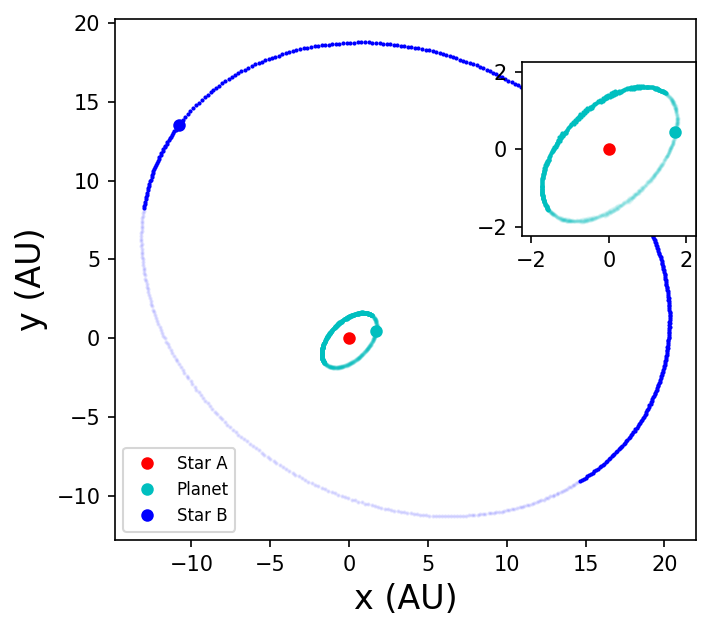

In [ ]:
sa = rebound.Simulationarchive(output_bin)

fig = plt.figure(figsize=(5,5),dpi=150)
ax = fig.add_subplot(111)
axins = ax.inset_axes([0.7, 0.5, 0.3, 0.5])
ax.set_aspect('equal')
axins.set_aspect('equal')

xy_coords = np.zeros((len(sa),9))
for s in range(0,len(sa)):
    sim = sa[s] #iterate through each snapshot in sa
    ps = sim.particles #intermediate object to simplify the referencing
    sim.move_to_hel() #shift to astrocentric coordinates
    for p in range(1,len(ps)):
        Cart = np.array([ps[p].x, ps[p].y, ps[p].z])
        rot_xy = Rot(-ps[2].Omega,-ps[2].inc,Cart)

        xy_coords[s,3*p] = rot_xy[0]
        xy_coords[s,3*p+1] = rot_xy[1]
        xy_coords[s,3*p+2] = rot_xy[2]

color = ['r','c','b']
label = ['Star A','Planet','Star B']
for p in range(0,3):
    pos_z = np.where(xy_coords[:,3*p+2]>=0)[0]
    neg_z = np.where(xy_coords[:,3*p+2]<0)[0]
    ax.plot(xy_coords[neg_z,3*p],xy_coords[neg_z,3*p+1],'.',color=color[p],ms=2,alpha=0.1)
    ax.plot(xy_coords[pos_z,3*p],xy_coords[pos_z,3*p+1],'.',color=color[p],ms=2)
    ax.plot(xy_coords[0,3*p],xy_coords[0,3*p+1],'.',color=color[p],ms=10,label=label[p])
    if p == 1:
        axins.plot(xy_coords[neg_z,3*p],xy_coords[neg_z,3*p+1],'.',color=color[p],ms=2,alpha=0.1)
        axins.plot(xy_coords[pos_z,3*p],xy_coords[pos_z,3*p+1],'.',color=color[p],ms=2)
        axins.plot(xy_coords[0,3*p],xy_coords[0,3*p+1],'.',color=color[p],ms=10)
        axins.plot(0,0,'r.',ms=10)
        axins.set_xlim(-2.25,2.25)
        axins.set_ylim(-2.25,2.25)

ax.set_xlabel("x (AU)",fontsize=16)
ax.set_ylabel("y (AU)",fontsize=16)

plt.legend(loc='lower left',fontsize=8);

## Run for 50,000 years to see the nodal precession of the planet

In [ ]:
output_bin = "gammaCep_long.bin"
output_steps = 200
simulation_S(5e4,output_bin,output_steps)

## Plot a series of figures to show how the orbit is changing with time

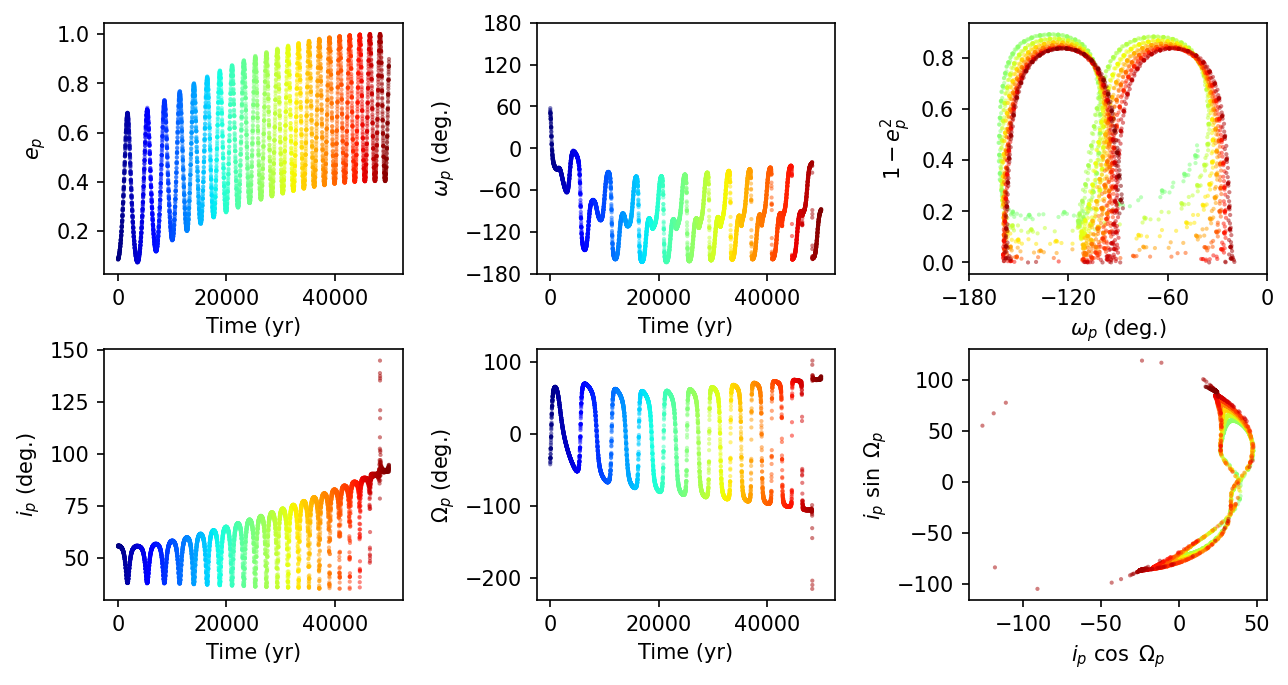

In [ ]:
t_max = 5e4
my_cmap = plt.colormaps['jet']
norm = cm.Normalize(vmin=0, vmax=t_max)

#plot the simulation
sa = rebound.Simulationarchive(output_bin)

fig = plt.figure(figsize=(10,5),dpi=150)
ax11 = fig.add_subplot(231)
ax12 = fig.add_subplot(232)
ax13 = fig.add_subplot(233)
ax21 = fig.add_subplot(234)
ax22 = fig.add_subplot(235)
ax23 = fig.add_subplot(236)

pl_orb = np.zeros((len(sa),6))
time = np.zeros(len(sa))
for s in range(0,len(sa)):
    sim = sa[s] #iterate through each snapshot in sa
    ps = sim.particles #intermediate object to simplify the referencing
    sim.move_to_hel() #shift to astrocentric coordinates
    time[s] = sim.t
    del_Omega = ps[2].Omega - ps[1].Omega
    omg_p = ps[1].omega
    if omg_p >= np.pi: omg_p -= 2*np.pi
    mut_incl = np.arccos(np.cos(ps[1].inc)*np.cos(ps[2].inc) + np.sin(ps[1].inc)*np.sin(ps[2].inc)*np.cos(del_Omega))
    pl_orb[s,:] = [ps[1].a,ps[1].e,np.degrees(mut_incl),omg_p,del_Omega,ps[1].M]

ax11.scatter(time,pl_orb[:,1],marker='o',c=time,norm=norm,edgecolor='None',s=4,alpha=0.5,cmap=my_cmap)
ax11.set_ylabel(r"$e_p$")
ax12.scatter(time,np.degrees(pl_orb[:,3]),marker='o',c=time,norm=norm,edgecolor='None',s=4,alpha=0.5,cmap=my_cmap)
ax12.set_ylabel(r"$\omega_p$ (deg.)")
start = int(len(sa)/2)
ax13.scatter(np.degrees(pl_orb[start:,3]),1.-pl_orb[start:,1]**2,marker='o',c=time[start:],norm=norm,edgecolor='None',s=4,alpha=0.5,cmap=my_cmap)
ax13.set_ylabel(r"$1-e_p^2$")

ax11.set_xlabel("Time (yr)")
ax12.set_xlabel("Time (yr)")
ax12.set_yticks(np.arange(-180,180+60,60))
ax13.set_xlabel(r"$\omega_p$ (deg.)")
ax13.set_xticks(np.arange(-180,60,60))

ax21.scatter(time,pl_orb[:,2],marker='o',c=time,norm=norm,edgecolor='None',s=4,alpha=0.5,cmap=my_cmap)
ax21.set_ylabel(r"$i_p$ (deg.)")
ax22.scatter(time,np.degrees(pl_orb[:,4]),marker='o',c=time,norm=norm,edgecolor='None',s=4,alpha=0.5,cmap=my_cmap)
ax22.set_ylabel(r"$\Omega_p$ (deg.)")
ax23.scatter(pl_orb[start:,2]*np.cos(pl_orb[start:,4]),pl_orb[start:,2]*np.sin(pl_orb[start:,4]),marker='o',c=time[start:],norm=norm,edgecolor='None',s=4,alpha=0.5,cmap=my_cmap)
ax23.set_ylabel(r"$i_p\ \sin\ \Omega_p$")

ax21.set_xlabel("Time (yr)")
ax22.set_xlabel("Time (yr)")
ax23.set_xlabel(r"$i_p\ \cos\ \Omega_p$")

fig.subplots_adjust(wspace=0.45,hspace=0.3);